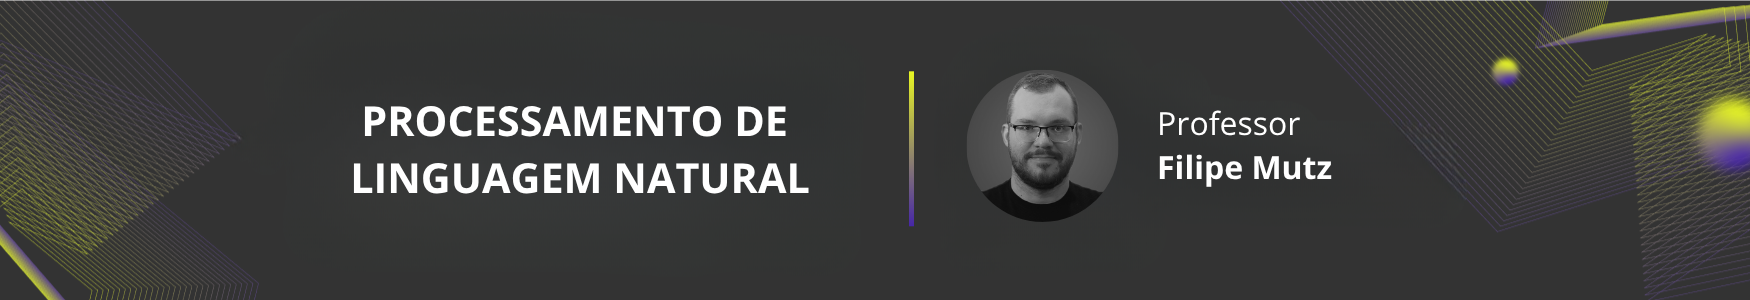

# 📝🤖 Speech-to-Text e Text-to-Speech

Este notebook tem como objetivo demonstrar como utilizar modelos para transcrição de áudio em texto (_Speech-to-Text_) e para geração de áudio a partir de textos (_Text-to-Speech_). Utilizaremos o modelo Whisper [RAD23] para a primeira tarefa e os modelos `Tacotron2` [SHE18] e `WaveRNN` [KAL18] para a segunda tarefa.


## Speech-to-Text com Whisper

O modelo Whisper recebe como entrada ondas sonoras de um áudio e gera como saída uma sequência de tokens representando o texto que existe nas ondas. Ele inicia convertendo as ondas sonoras em um espectrograma log-mel que mostra como a frequência das ondas varia ao longo do tempo. Este espetrograma é usado como entrada para algumas camadas convolucionais e, em seguida, para uma arquitetura codificador-decodificador (_encoder-decoder_) baseada em camadas do tipo Transformer.

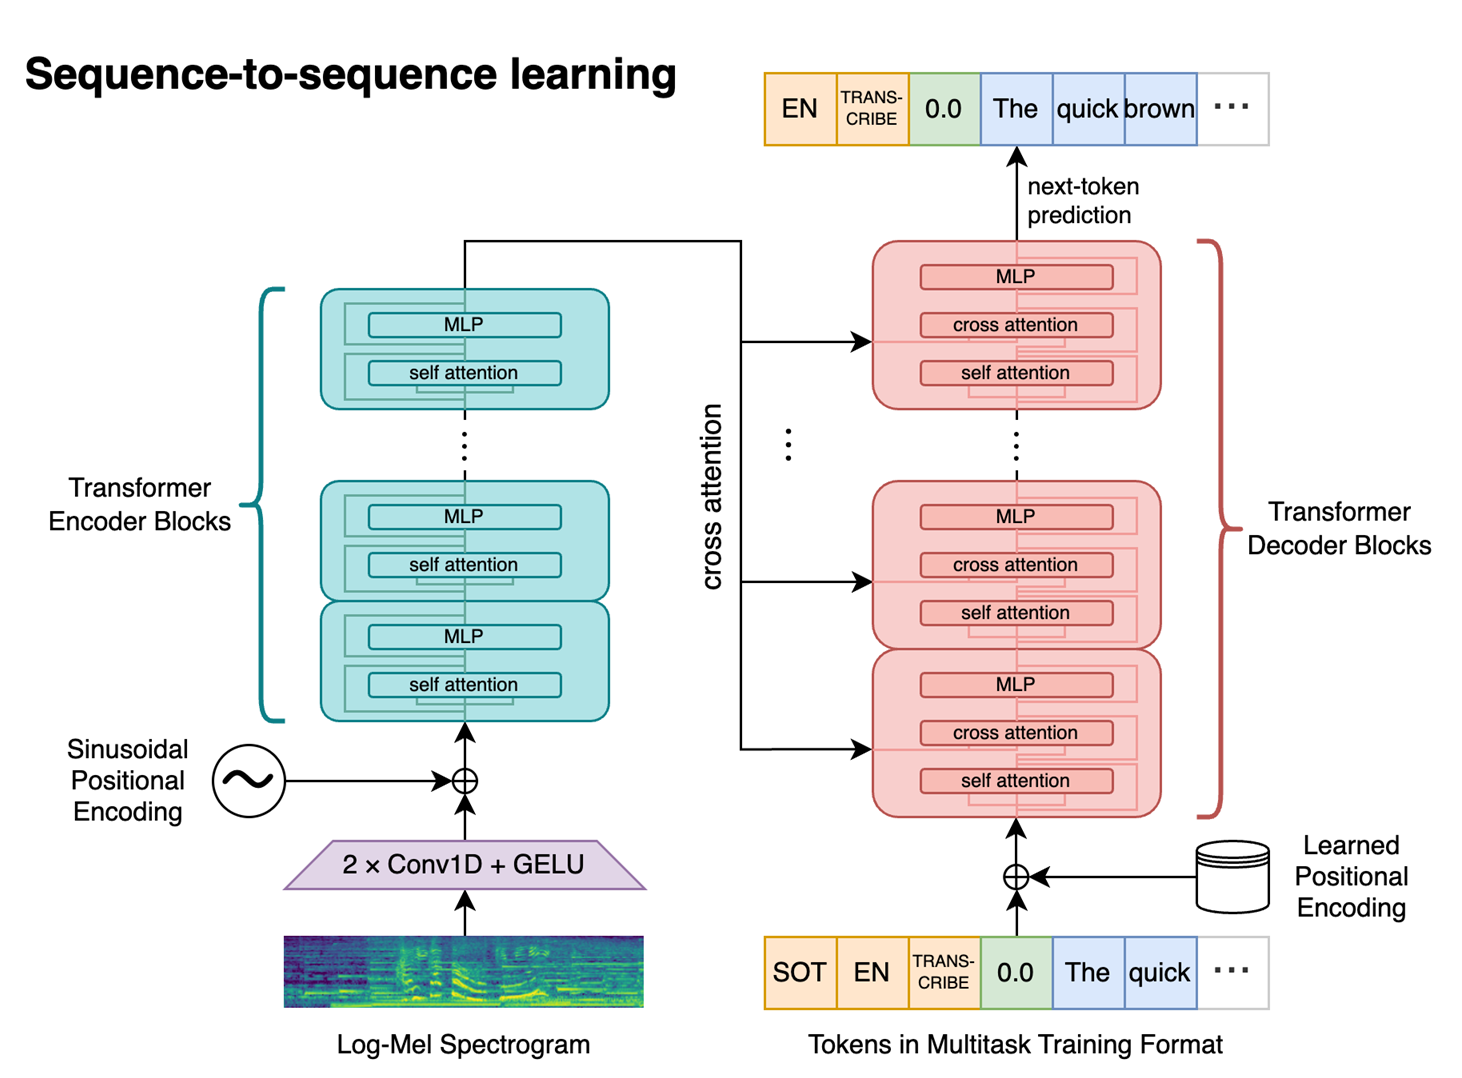

Para demonstrar o uso do modelo, vamos usar um áudio de um base de dados em português. Outras amostras podem ser encontradas [neste link](https://edresson.github.io/TTS-Portuguese-Corpus/). A célula abaixo faz o download do áudio e mostra um controle para permitir tocá-lo no browser.

In [ ]:
!wget https://edresson.github.io/TTS-Portuguese-Corpus/audio/Esperado/11.wav

from IPython.display import Audio, display
display(Audio("11.wav"))

--2025-08-04 14:20:41--  https://edresson.github.io/TTS-Portuguese-Corpus/audio/Esperado/11.wav
Resolving edresson.github.io (edresson.github.io)... 185.199.111.153, 185.199.108.153, 185.199.109.153, ...
Connecting to edresson.github.io (edresson.github.io)|185.199.111.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 404204 (395K) [audio/wav]
Saving to: ‘11.wav’

11.wav              100%[===================>] 394.73K  --.-KB/s    in 0.04s   

2025-08-04 14:20:41 (10.6 MB/s) - ‘11.wav’ saved [404204/404204]



Vamos utilizar um modelo [pré-treinado disponibilizado pela Huggingface (biblioteca transformer)](https://huggingface.co/openai/whisper-medium). Dado um áudio, precisamos realizar e extração das ondas sonoras no formato esperado pelo modelo.

In [ ]:
import torch
import torchaudio

# Carrega o áudio usando torchaudio
waveform, sr = torchaudio.load("11.wav")

# Converte para mono se for estéreo
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)

# Faz resample para 16000 Hz se necessário (esperado pelo Whisper)
if sr != 16000:
    resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
    waveform = resampler(waveform)
    sr = 16000

# Remove a dimensão batch
waveform = waveform.squeeze().numpy()
waveform.shape

(67360,)

A célula abaixo faz o download do modelo Whisper pré-treinado, além das classes para preprocessamento e decodificação da resposta em texto. Esta célula pode **demorar alguns minutos** para ser executada na primeira vez pela necessidade de download do modelo.

In [ ]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset

# load model and processor
processor = WhisperProcessor.from_pretrained("openai/whisper-medium")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-medium")
forced_decoder_ids = processor.get_decoder_prompt_ids(language="portuguese", task="transcribe")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [ ]:

from time import time

start = time()

# preprocessamento das ondas sonoras
input_features = processor(waveform, sampling_rate=sr, return_tensors="pt").input_features

# envia o modelo e os dados para a placa de vídeo
model = model.to('cuda')
input_features = input_features.to('cuda')

# gera tokens a partir do audio
predicted_ids = model.generate(input_features, forced_decoder_ids=forced_decoder_ids)

# decodifica tokens em textos
transcription = processor.batch_decode(predicted_ids, skip_special_tokens=True)

print(f"Transcrição: {transcription} - Tempo: {time() - start:.3f}s")


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Transcrição: [' A Amazônia é a reserva ecológica do globo.'] - Tempo: 10.142s


## Text-to-Speech com Tacotron2 e WaveRNN

Esta seção demonstra como converter texto em fala utilizando modelos pré-treinados do torchaudio.

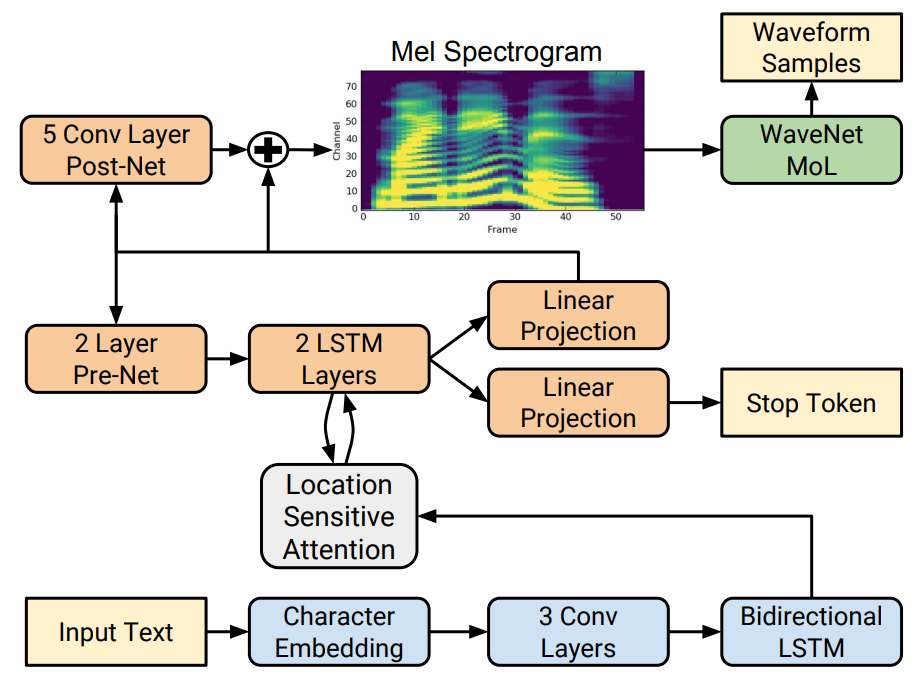

### Fundamentação


O processo consiste nas seguintes etapas:

1. **Pré-processamento do texto:** Primeiro, o texto de entrada é codificado em uma lista de símbolos. Neste tutorial, usaremos caracteres e fonemas do inglês como símbolos.

2. **Geração de espectrograma**: A partir do texto codificado, é gerado um espectrograma. Usamos o modelo `Tacotron2` [SHE18] para isso.

3. **Conversão para o domínio do tempo**: A última etapa é converter o espectrograma em onda sonora. O processo de gerar fala a partir de um espectrograma também é chamado de vocoder. Vamos utilizar o modelo `WaveRNN` [KAL18] para isto.


### Código

A biblioteca `torchaudio` provê pipelines contendo as etapas necessárias para transformar textos em áudios. A célula abaixo extrai o preprocessador de texto, gerador de espetrograma e o vocoder do pipeline `TACOTRON2_WAVERNN_CHAR_LJSPEECH`.

In [ ]:
import torchaudio

device = 'cuda'

# pipeline para geração de áudio
bundle = torchaudio.pipelines.TACOTRON2_WAVERNN_CHAR_LJSPEECH

# codificador de texto
processor = bundle.get_text_processor()

# modelo para geração de espetrograma
tacotron2 = bundle.get_tacotron2().to(device)

# gerador de ondas sonoras a partir do espectrograma
vocoder = bundle.get_vocoder().to(device)


A célula abaixo realiza o preprocessamento do texto que consiste em quebrar o texto em unidades menores e codificar as unidades.

In [ ]:
import torch

text = "Hello world! Artificial intelligence and data science are awesome!"

with torch.inference_mode():
  processed, lengths = processor(text)

processed

tensor([[19, 16, 23, 23, 26, 11, 34, 26, 29, 23, 15,  2, 11, 12, 29, 31, 20, 17,
         20, 14, 20, 12, 23, 11, 20, 25, 31, 16, 23, 23, 20, 18, 16, 25, 14, 16,
         11, 12, 25, 15, 11, 15, 12, 31, 12, 11, 30, 14, 20, 16, 25, 14, 16, 11,
         12, 29, 16, 11, 12, 34, 16, 30, 26, 24, 16,  2]])

A célula abaixo utiliza o sistema o `tacotron2` para gerar o espetrograma.

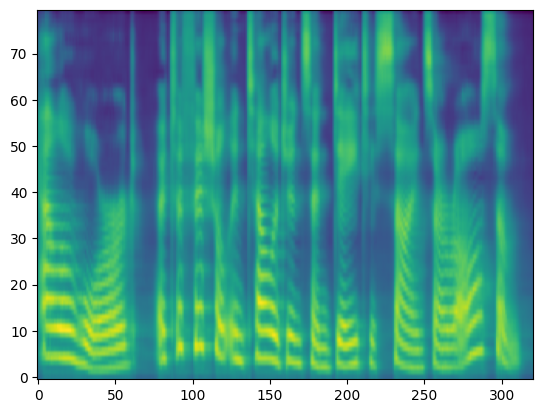

In [ ]:
import matplotlib.pyplot as plt

with torch.inference_mode():
  processed = processed.to(device)
  lengths = lengths.to(device)
  spec, spec_lengths, _ = tacotron2.infer(processed, lengths)

plt.imshow(spec[0].cpu().detach(), origin="lower", aspect="auto")

Por fim, o vocoder `WaveRNN` é utilizado para gerar as ondas sonoras a partir do espetrograma.

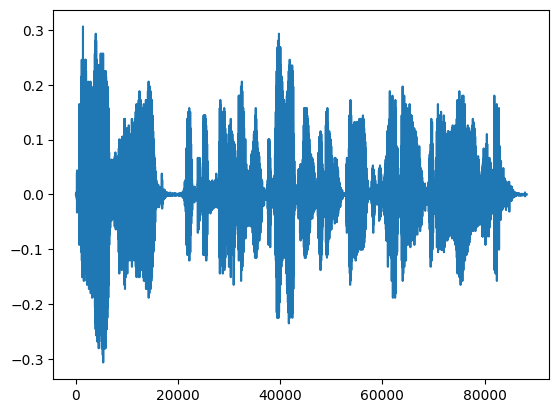

In [ ]:
import IPython

with torch.inference_mode():
  waveforms, lengths = vocoder(spec, spec_lengths)

waveforms = waveforms.cpu().detach()

plt.plot(waveforms[0])
IPython.display.Audio(waveforms[0:1], rate=vocoder.sample_rate)


## Conclusão

Este notebook demonstrou como utilizar modelos pré-treinados para conversão de áudio em texto e texto em voz. Estes tipos de modelos podem ser utilizados em diversas aplicações, por exemplo, o desenvolvimento de interfaces de interação com usuário por voz ou mineração de dados que estão disponíveis em formato de áudio.



## Referências

- [RAD23] Radford, A., Kim, J. W., Xu, T., Brockman, G., McLeavey, C., & Sutskever, I. (2023, July). Robust speech recognition via large-scale weak supervision. In International conference on machine learning (pp. 28492-28518). PMLR.

- [SHE18] Shen, J., Pang, R., Weiss, R. J., Schuster, M., Jaitly, N., Yang, Z., ... & Wu, Y. (2018, April). Natural tts synthesis by conditioning wavenet on mel spectrogram predictions. In 2018 IEEE international conference on acoustics, speech and signal processing (ICASSP) (pp. 4779-4783). IEEE.

- [KAL18] Kalchbrenner, N., Elsen, E., Simonyan, K., Noury, S., Casagrande, N., Lockhart, E., et al. Efficient neural audio synthesis. In International Conference on Machine Learning (pp. 2410-2419). PMLR. 2018.
